# Language Models for Text Classification with the AG News Dataset — Student Version

In this notebook, you will progressively build a small prompting-based text classification pipeline with the **AG News** dataset.

## Learning goals
- load and inspect a text classification dataset
- design **zero-shot** and **few-shot** prompts
- query **two LLM APIs** (**Groq** and **Mistral**)
- normalize model outputs
- evaluate predictions on a small test subset
- reflect on strengths and limitations of prompting for classification


## 1. Setup

This notebook should use:
- `datasets` for AG News
- `pandas` and `matplotlib` for quick inspection
- `groq` for one API
- `mistralai` for a second API

> Keep API keys out of the notebook when possible.

In [16]:
# TODO: uncomment and run if needed
#!pip install -q datasets pandas matplotlib groq mistralai

In [17]:
import os
import re
import json
import random
import time
from typing import List, Dict, Optional

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from openai import OpenAI
from groq import Groq

In [ ]:
SEED = 42

# TODO: set the random seed

# Small subsets keep the demo fast and avoid exhausting free quotas.
TRAIN_SUBSET = 24
TEST_SUBSET = 20

LABELS = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

# TODO:
# 1) set your API keys in the environment before running
# 2) read them with os.getenv(...)
# 3) print a quick check (True / False)

# Example in a terminal:
# export GROQ_API_KEY="..."
# export MISTRAL_API_KEY="..."

GROQ_API_KEY = "..."
MISTRAL_API_KEY = "..."

GROQ_MODEL = "llama-3.3-70b-versatile"
MISTRAL_MODEL = "ministral-14b-2512"

print("Groq key loaded:", ...)
print("Mistral key loaded:", ...)

Groq key loaded: Ellipsis
Mistral key loaded: Ellipsis


## 2. Load and inspect AG News

AG News contains four topic classes:
1. World
2. Sports
3. Business
4. Sci/Tech

Each example contains a piece of text and a numeric label.

In [19]:
print("Loading AG News...")
dataset = load_dataset("ag_news")

train_data = dataset["train"].shuffle(seed=SEED)
test_data = dataset["test"].shuffle(seed=SEED)

if TRAIN_SUBSET is not None:
    train_data = train_data.select(range(TRAIN_SUBSET))
if TEST_SUBSET is not None:
    test_data = test_data.select(range(TEST_SUBSET))

print(dataset)
print("Train subset size:", len(train_data))
print("Test subset size:", len(test_data))

Loading AG News...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Train subset size: 24
Test subset size: 20


In [20]:
# TODO: convert the subsets to pandas DataFrames
df_train = train_data.to_pandas()
df_test = test_data.to_pandas()

# TODO: map numeric labels to label names
df_train["label_name"] = df_train["label"].map(LABELS)
df_test["label_name"] = df_test["label"].map(LABELS)

# TODO: inspect a few rows
display(df_train.head())
display(df_test.head())

,text,label,label_name
0,Bangladesh paralysed by strikes Opposition act...,0,World
1,Desiring Stability Redskins coach Joe Gibbs ex...,1,Sports
2,Will Putin #39;s Power Play Make Russia Safer?...,0,World
3,U2 pitches for Apple New iTunes ads airing dur...,3,Sci/Tech
4,S African TV in beheading blunder Public broad...,0,World


,text,label,label_name
0,Indian board plans own telecast of Australia s...,1,Sports
1,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
2,"Nuggets 112, Raptors 106 Carmelo Anthony score...",1,Sports
3,Stocks Higher on Drop in Jobless Claims A shar...,2,Business
4,REVIEW: 'Half-Life 2' a Tech Masterpiece (AP) ...,3,Sci/Tech


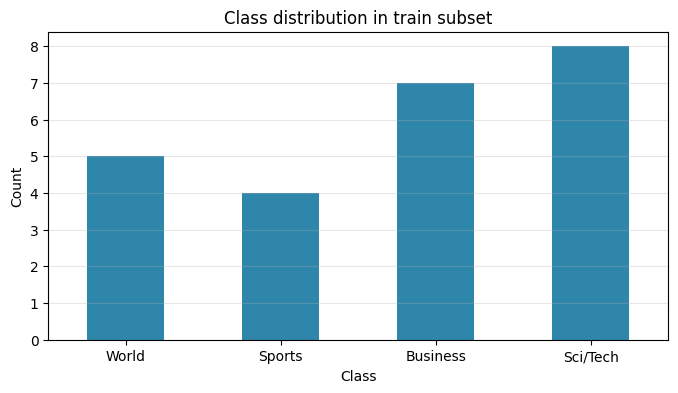

In [21]:
# TODO: plot the class distribution in the train subset

if "label_name" not in df_train.columns:
    df_train["label_name"] = df_train["label"].map(LABELS)

class_counts = (
    df_train["label_name"]
    .value_counts()
    .reindex(list(LABELS.values()), fill_value=0)
)

plt.figure(figsize=(8, 4))
class_counts.plot(kind="bar", color="#2E86AB")
plt.title("Class distribution in train subset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 3. Build prompts

We want the model to return **only one** of these labels:
- `World`
- `Sports`
- `Business`
- `Sci/Tech`

### TODOs
- understand why constrained output matters
- compare **zero-shot** and **few-shot**
- decide what makes a good support example

In [22]:
def format_example(example):
    # TODO:
    # return a formatted string version of one AG News example
    # You may include:
    # - the title
    # - the full text
    # Keep the format simple and consistent.
    title = str(example.get("title", "")).strip()
    text = str(example.get("text", "")).strip()
    return f"Title: {title}\nText: {text}"

In [23]:
def build_zero_shot_prompt(example):
    labels_text = ", ".join(LABELS.values())
    prompt = f"""
You are a news topic classifier.

Possible labels: {labels_text}

Instructions:
- Choose exactly one label from the list above.
- Do not explain.
- Output only the label text.

News:
{format_example(example)}

Label:
"""
    return prompt.strip()

In [24]:
def build_few_shot_prompt(example, support_examples):
    # TODO:
    # create a few-shot prompt using support examples
    #
    # Requirements:
    # - reuse the same instruction style as zero-shot
    # - include labeled examples before the test item
    # - keep formatting identical across examples
    # - finish with the unlabeled target example
    #
    # Optional challenge:
    # - try 1 example per class
    # - later try 2 examples per class

    labels_text = ", ".join(LABELS.values())
    support_lines = []

    # TODO: loop through support_examples and build the support block
    for ex in support_examples:
        support_lines.append(format_example(ex))
        support_lines.append(f"Label: {LABELS[ex['label']]}")
        support_lines.append("")  # blank line between examples

    support_block = "\n".join(support_lines).strip()

    prompt = f"""
You are a news topic classifier.

Possible labels: {labels_text}

Instructions:
- Choose exactly one label from the list above.
- Do not explain.
- Output only the label text.

Labeled examples:
{support_block}

Now classify this unlabeled example:
{format_example(example)}

Label:
"""
    return prompt.strip()

## 4. API helpers

We will compare:
1. **Groq**
2. **Mistral**

Both functions should receive a prompt and return the model's raw text output.

In [25]:
# TODO: initialize the Groq client
groq_client = Groq(api_key=GROQ_API_KEY)

def ask_groq(prompt, model=GROQ_MODEL):
    # TODO:
    # complete the API call
    # Hints:
    # - use a chat completion
    # - pass the prompt as a user message
    # - use temperature=0 for deterministic behavior
    # - keep max_tokens small
    response = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=16,
    )

    # TODO: return only the text content
    return response.choices[0].message.content.strip()


In [26]:
# TODO: initialize the Mistral client
from mistralai.client import Mistral

mistral_client = Mistral(api_key=MISTRAL_API_KEY)


def ask_mistral(prompt, model=MISTRAL_MODEL):
    # TODO:
    # complete the API call using the official Mistral client
    # Hints:
    # - use client.chat.complete(...)
    # - pass one user message
    # - keep the answer short
    response = mistral_client.chat.complete(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=16,
    )

    # TODO: return only the text content
    return response.choices[0].message.content.strip()


In [27]:
VALID_LABELS = set(LABELS.values())

def normalize_prediction(text):
    # TODO:
    # convert a raw model answer into one of the valid labels or None
    #
    # Suggested steps:
    # 1) handle None
    # 2) strip whitespace
    # 3) check exact match
    # 4) fallback: search for one valid label inside a longer sentence
    if text is None:
        return None

    cleaned = str(text).strip()
    if not cleaned:
        return None

    if cleaned in VALID_LABELS:
        return cleaned

    cleaned_lower = cleaned.lower()
    for label in LABELS.values():
        if label.lower() in cleaned_lower:
            return label

    return None


In [28]:
def evaluate_predictions(predictions, gold_ids):
    # TODO:
    # return a DataFrame with:
    # - gold_id
    # - gold_label
    # - prediction
    # - correct (True/False)

    rows = []

    # TODO: fill rows
    for pred, gold_id in zip(predictions, gold_ids):
        gold_label = LABELS.get(gold_id)
        rows.append(
            {
                "gold_id": gold_id,
                "gold_label": gold_label,
                "prediction": pred,
                "correct": pred == gold_label,
            }
        )

    return pd.DataFrame(rows)


## 5. Zero-shot classification

In zero-shot prompting, the model gets **instructions only**, with **no labeled examples**.

### TODOs
- test each API on a very small subset first
- inspect the raw outputs
- check whether the model respects the required format

In [29]:
def run_experiment(
    dataset_split,
    ask_fn,
    prompt_builder,
    support_examples=None,
    sleep_seconds=0.0,
):
    predictions = []
    raw_outputs = []

    for example in dataset_split:
        # TODO:
        # - build the prompt
        # - call the API
        # - normalize the answer
        # - store both raw and normalized outputs
        # - handle errors with try/except
        try:
            if support_examples is None:
                prompt = prompt_builder(example)
            else:
                prompt = prompt_builder(example, support_examples)

            raw = ask_fn(prompt)
            pred = normalize_prediction(raw)

        except Exception as e:
            raw = f"ERROR: {e}"
            pred = None

        raw_outputs.append(raw)
        predictions.append(pred)

        # TODO: optional pause to respect rate limits
        if sleep_seconds and sleep_seconds > 0:
            time.sleep(sleep_seconds)

    return predictions, raw_outputs


In [30]:
# TODO:
# 1) create a tiny test slice (for example, 5 items)
# 2) extract the gold labels
# 3) run zero-shot with Groq
# 4) run zero-shot with Mistral
# 5) display evaluation tables
# 6) print the raw outputs to inspect formatting

tiny_test = test_data.select(range(5))
gold_tiny = [ex["label"] for ex in tiny_test]

zs_groq_preds, zs_groq_raw = run_experiment(
    dataset_split=tiny_test,
    ask_fn=ask_groq,
    prompt_builder=build_zero_shot_prompt,
    support_examples=None,
    sleep_seconds=0.0,
)

zs_mistral_preds, zs_mistral_raw = run_experiment(
    dataset_split=tiny_test,
    ask_fn=ask_mistral,
    prompt_builder=build_zero_shot_prompt,
    support_examples=None,
    sleep_seconds=0.0,
)

display(evaluate_predictions(zs_groq_preds, gold_tiny))
display(evaluate_predictions(zs_mistral_preds, gold_tiny))

print("Groq raw outputs:", zs_groq_raw)
print("Mistral raw outputs:", zs_mistral_raw)


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True


Groq raw outputs: ['Sports', 'Business', 'Sports', 'Business', 'Sci/Tech']
Mistral raw outputs: ['Sports', 'Business', 'Sports', 'Business', 'Sci/Tech']


## 6. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

### TODOs
- build a support set
- start with **one example per class**
- later try more examples
- reflect on whether support example choice changes the results

In [31]:
# TODO:
# create a support set from the training subset
#
# Suggested strategy:
# - pick one example for each label
# - store them in support_examples
# - verify that all 4 labels are covered

support_examples = []
seen = set()

# Your code here
for ex in train_data:
    label_id = ex["label"]
    if label_id not in seen:
        support_examples.append(ex)
        seen.add(label_id)
    if len(seen) == len(LABELS):
        break

print("Covered labels:", [LABELS[i] for i in sorted(seen)])
print("All 4 labels covered:", len(seen) == len(LABELS))

for ex in support_examples:
    # TODO: print the label name and formatted example
    print(LABELS[ex["label"]])
    print(format_example(ex))
    print("-" * 80)


Covered labels: ['World', 'Sports', 'Business', 'Sci/Tech']
All 4 labels covered: True
World
Title: 
Text: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.
--------------------------------------------------------------------------------
Sports
Title: 
Text: Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington.
--------------------------------------------------------------------------------
Sci/Tech
Title: 
Text: U2 pitches for Apple New iTunes ads airing during baseball games Tuesday will feature the advertising-shy Irish rockers.
--------------------------------------------------------------------------------
Business
Title: 
Text: Economy builds steam in KC Fed district The economy continued to strengthen in September and early October in the Great Plains a

In [32]:
# TODO:
# run few-shot classification on the full test subset with both APIs

gold_test = [ex["label"] for ex in test_data]

fs_groq_preds, fs_groq_raw = run_experiment(
    dataset_split=test_data,
    ask_fn=ask_groq,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
    sleep_seconds=0.0,
)

fs_mistral_preds, fs_mistral_raw = run_experiment(
    dataset_split=test_data,
    ask_fn=ask_mistral,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
    sleep_seconds=0.0,
)

df_fs_groq = evaluate_predictions(fs_groq_preds, gold_test)
df_fs_mistral = evaluate_predictions(fs_mistral_preds, gold_test)

display(df_fs_groq)
display(df_fs_mistral)


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True
5,0,World,Business,False
6,2,Business,Business,True
7,2,Business,Business,True
8,3,Sci/Tech,Sci/Tech,True
9,2,Business,Business,True


,gold_id,gold_label,prediction,correct
0,1,Sports,Sports,True
1,2,Business,Business,True
2,1,Sports,Sports,True
3,2,Business,Business,True
4,3,Sci/Tech,Sci/Tech,True
5,0,World,World,True
6,2,Business,Business,True
7,2,Business,Business,True
8,3,Sci/Tech,Sci/Tech,True
9,2,Business,Business,True


## 7. Compare zero-shot vs few-shot

You should now have four settings:
- Groq zero-shot
- Groq few-shot
- Mistral zero-shot
- Mistral few-shot

### TODOs
- compute accuracy for each setting
- compare the numbers
- identify at least 2 error cases

,experiment,accuracy
0,Groq zero-shot,1.00
2,Mistral zero-shot,1.00
1,Groq few-shot,0.95
3,Mistral few-shot,0.95


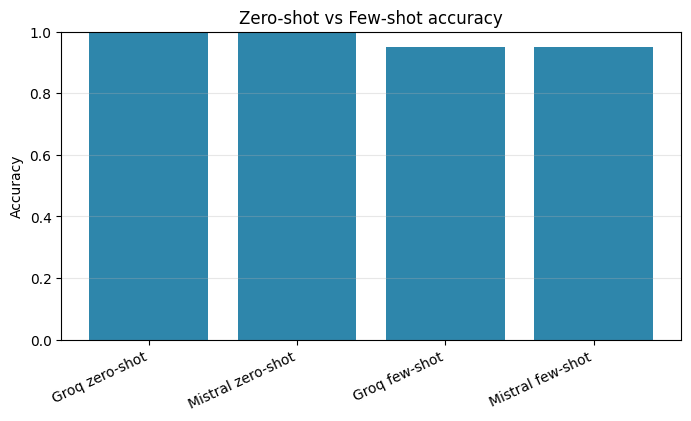

In [33]:
def accuracy(preds, gold_ids):
    # TODO:
    # compute simple accuracy
    if len(gold_ids) == 0:
        return 0.0
    return sum(p == LABELS[g] for p, g in zip(preds, gold_ids)) / len(gold_ids)

results = {
    # TODO: fill this dictionary with the four accuracies
    # "Groq zero-shot": ...,
    # "Groq few-shot": ...,
    # "Mistral zero-shot": ...,
    # "Mistral few-shot": ...,
    "Groq zero-shot": accuracy(zs_groq_preds, gold_tiny),
    "Groq few-shot": accuracy(fs_groq_preds, gold_test),
    "Mistral zero-shot": accuracy(zs_mistral_preds, gold_tiny),
    "Mistral few-shot": accuracy(fs_mistral_preds, gold_test),
}

results_df = pd.DataFrame(
    [{"experiment": k, "accuracy": v} for k, v in results.items()]
).sort_values("accuracy", ascending=False)
display(results_df)

# TODO: optional bar plot of the four accuracies
plt.figure(figsize=(8, 4))
plt.bar(results_df["experiment"], results_df["accuracy"], color="#2E86AB")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Zero-shot vs Few-shot accuracy")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 8. Reflection questions

Answer briefly in your own words.

1. Did few-shot improve performance?
2. Which classes seemed easiest or hardest?
3. Were the outputs always clean and easy to parse?
4. How sensitive were the results to prompt wording?
5. What are the limitations of API-based prompting for classification?
6. When would you prefer a supervised classifier instead?

## 9. Optional extensions

Choose one or more:

- Try **2 support examples per class**
- Compare **headline only** vs **full text**
- Force the model to output a **JSON object**
- Build a **confusion matrix**
- Measure **latency** per API
- Estimate **cost / quota usage**
- Intentionally use **biased support examples** and observe what changes

## 10. Final takeaway

Large language models can perform classification through prompting alone.

### Before finishing, make sure you completed:
- [ ] dataset loading
- [ ] zero-shot prompt
- [ ] few-shot prompt
- [ ] Groq helper
- [ ] Mistral helper
- [ ] normalization
- [ ] evaluation
- [ ] comparison
- [ ] reflection